# Resting Batch Face 

### Från 😐 till 😡 med Convolutional Neural Networks

----

I detta projekt utforskas och utvärderas olika strategier och optimeringstaktiker för att förbättra prestandan hos CNN-modeller vid klassificering av ansiktsuttryck baserat på FER-2013 datasetet.

Notebooken går igenom hela processen från dataanalys och förbehandling till modellträning, utvärdering och prediktioner på ny data, samt en analys och reflektion kring modellernas olika resultat.

In [80]:
# --- SETUP & IMPORTS ---

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

from pathlib import Path

from PIL import Image

import random

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers, optimizers
from keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

## 1. Dataanalys

### 1.1 Antal bilder

#### 1.1.1 Total, Train & Test

In [2]:
def count_images(path):
    """
    Funktion för att räkna antalet filer som slutar på .jpg eller .png i en given mapp.

    path (Path):
        En pathlib.Path-sökväg till mappen som ska "skannas"

    Returnerar totalt antal bilder hittade i mappen (och dess undermappar) (int)
    """
    return len(list(path.rglob("*.jpg"))) + len(list(path.rglob("*jpeg"))) + len(list(path.rglob("*.png")))

# Skapar sökväg till huvudmappen
data_dir = Path("data")

# Räknar antalet bilder i mapparna data, train och test
train_count = count_images(data_dir / "train")
test_count = count_images(data_dir / "test")
total_count = train_count + test_count

# Räknar ut andel 
train_percent = (train_count / total_count) * 100
test_percent = (test_count / total_count) * 100
total_percent = train_percent + test_percent

# Skapar data till statestik-tabell
stats_images = {
    "Set": ["Train", "Test", "Total"],
    "Antal bilder": [train_count, test_count, total_count],
    "Andel": [f"{train_percent:.1f}%", f"{test_percent:.1f}%", f"{total_percent:.1f}%"]
}

df_stats_images = pd.DataFrame(stats_images)

df_stats_images

,Set,Antal bilder,Andel
0,Train,28691,80.0%
1,Test,7178,20.0%
2,Total,35869,100.0%


https://docs.python.org/3/library/pathlib.html

https://www.geeksforgeeks.org/python/pathlib-module-in-python/ 

Path från pathlib är det enklare och mer moderna sättet att hantera sökvägar jämfört med os.path då pathlib hanterar sökvägarna som objekt istället för vanliga strängar. 

Path-objekt kommer med en metod rglob() vilket gör det möjligt att leta vidare i undermappar (och FER-2013 verkar inte bestå av annat än mappar hit och dit). 

Motsvarigheten till rglob() är bara glob() som "stannar" vid första mappen istället för att gå djupare ner i mappstrukturen.

rglob() returnerar en så kallad generator, vilket bara "går förbi" filerna i mapparna och lägger inte dem på minnet. 

list() behövs då för att generatorn ska faktiskt ska samla på sig alla bilder så att det sen går att räkna dem med len().

#### 1.1.2 Klasserna

In [3]:
def get_class_dataframe(folder_path, total_set_count):
    """
    Skapar en DataFrame med statistik för alla klasser (undermappar).

    folder_path:
        Sökvägen till mappen.
    
    total_set_count:
        Totala antalet bilder i den mappen (för att räkna ut andel).

    Returnerar en pd.DataFrame
    """

    stats_list = []
    stray_files_found = []

    # Loop för att gå igenom varje undermapp och ta ut statistik för den (= antalet bilder)
    for class_path in sorted(folder_path.iterdir()):
        if class_path.is_dir():
            count = count_images(class_path)
            percent = (count / total_set_count) * 100

            stats_list.append({
                "Klass": class_path.name,
                "Antal": count,
                "Andel": f"{percent:.1f}%"
            })
        else:
            stray_files_found.append(class_path.name)

    if stray_files_found:
        print(f"Meddelande för '{folder_path.name}': Det finns filer utanför mapparna.")
    else:
        print(f"Meddelande för '{folder_path.name}': Det finns inga filer utanför mapparna.")

    return pd.DataFrame(stats_list)

iterdir() "öppnar" mappen i fråga (i den här rapporten antingen "train" eller "test") och säger vilka andra mappar som finns i den, alltså klasserna. På så vis får vi klassnamnen. 

sorted() gör att loopen går igenom undermapparna i bokstavsordning (så det alltid blir samma ordning).

is_dir() kontrollerar att det är en mapp. Om det inte är en mapp läggs filen i listan stray_files_found. 

Om det är en mapp används funktionen count_images för att räkna antalet bilder för den aktuella klassmappen. 

Varje klassinformation sparas som en dictionary i listan stats_list för att det ska gå enkelt att göra en pd.DataFrame sen. 

Och på slutet så ligger det en kontroll som talar om att det finns eller inte finns lösa filer utanför mapparna. (En liten check för att se hur städad datan är)

In [4]:
# Skriver ut statistik-tabellen för "train"
df_train = get_class_dataframe(data_dir / "train", train_count)

df_train

Meddelande för 'train': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,3977,13.9%
1,disgust,436,1.5%
2,fear,4097,14.3%
3,happy,7215,25.1%
4,neutral,4965,17.3%
5,sad,4830,16.8%
6,surprise,3171,11.1%


In [5]:
# Skriver ut statistik-tabellen för "test"
df_test = get_class_dataframe(data_dir / "test", test_count)

df_test

Meddelande för 'test': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,958,13.3%
1,disgust,111,1.5%
2,fear,1024,14.3%
3,happy,1774,24.7%
4,neutral,1233,17.2%
5,sad,1247,17.4%
6,surprise,831,11.6%


#### 1.1.3 Slutsats kontroll av antalet bilder

- FER-2013 är vid nedladdning redan uppdelat i tränings- och testdata med en fördelning på 80 % träningsdata och 20 % testdata.
- Det finns en obalans mellan klasserna i "train" där träningsdatan till 25% består av "happy" men bara till 1,5% av "disgust". Övriga klasser är fördelade någorlunda jämnt inom spannet 11-17%.
- Den obalans som råder i "train" ser likadan ut i "test". 


### 1.2 Bildformat

In [6]:
# Går igenom ALLA bilder för att plocka ut alla olika typer av bildstorlekar, bildformat och färgskala. 
all_sizes = set()
all_formats = set()
all_modes = set()

for img_path in data_dir.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        with Image.open(img_path) as img:
            all_sizes.add(img.size)
            all_formats.add(img.format)
            all_modes.add(img.mode)

https://docs.python.org/3/tutorial/datastructures.html#sets 

https://pillow.readthedocs.io/en/stable/reference/Image.html

https://pillow.readthedocs.io/en/stable/reference/open_files.html#file-handling

set() skapar en tom "behållare" som är lite som en lista, fast oordnad och som inte kan innehålla dubletter. Vilket passar bra när jag bara vill veta vilka olika varianter det finns, inte hur många av varje. 

img_path.suffix.lower() säkerställer att koden bara försöker bearbeta filer som faktiskt är bilder (.jpg, .jpeg, .png).

Image.open() skapar ett objekt (i det här fallet img) som gör det möjligt att göra en massa roligt med det objektet/bilden sedan, som exempelvis show() eller resize(). 

Men helt ensam gör den inte så mycket, förutom just *det* som jag vill åt: extrahera bildstorlek, bildformat och färgskala. 

Image.open() lämnar normalt filen öppen liten grann, men genom att använda with stängs den igen vilket gör att det går att kolla igenom 35 000 + bilder utan att datorn exploderar. 

In [7]:
# Skriver ut resultatet från kodcellen innan
print(f"Unika storlekar: {all_sizes}")
print(f"Unika format: {all_formats}")
print(f"Unika modes: {all_modes}")

Unika storlekar: {(48, 48)}
Unika format: {'JPEG'}
Unika modes: {'L'}


#### 1.2.1 Slutsats bildformat

Alla bilder har samma storlek (48 x 48), samma format (jpg) och är i gråskala (L) (motsvarande för färg är RGB).

### 1.3 Visuell kontroll

In [8]:
# Plocka ut fem slumpmässiga bilder från varje klass i "train" och plottar dem i samma figur
random.seed(42)

n_samples = 5
train_path = data_dir / "train"
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])

preview_fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))

for i, label in enumerate(classes):
    class_dir = train_path / label
    all_imgs = list(class_dir.glob("*.jpg"))

    samples = random.sample(all_imgs, n_samples)

    for j, img_path in enumerate(samples):
        with Image.open(img_path) as img:
            ax = axes[i, j]
            ax.imshow(img, cmap="grey")
            ax.axis("off")

            if j == 0:
                ax.set_title(label, loc="left", fontweight="bold")

plt.tight_layout()

plt.close(preview_fig)

train_path = data_dir / "train" skapar en sökväg till träningsmappen. 

classes = sorted([...]) skapar en lista med namnen på alla klasser (undermappar) i bokstavsordning. (Allt som inte är en mapp ignoreras)

preview_fig, axes = ... här skapas en figur med flera rader och kolumner. Eftersom varje rad ska innehålla 5 bilder från de olika klasserna blir antalet rader hur många klasser det finns (len(classes)) och antalet kolumner blir antalet bilder som ska visas (i det här fallet n_samples = 5). 

Sedan startas en loop som går igenom varje klass. i är klassens radnummer i figuren och label är namnet på klassen. 

class_dir = train_path / label skapar en sökväg till den aktuella klassens mapp. 

Alla bilder i den aktuella mappen sparas i en lista, all_imgs. Sedan väljs fem slumpmässiga bilder i listan ut. 

Den inre loopen går igenom de fem valda bilderna. Varje bild öppnas med Image.open() och får en korrekt plats i plotten med ax = axes[i, j] där i = raden (klassen) och ju = kolumnnummer. 

ax.imshow(img) gör att bilden visas i den valda rutan i figuren. ax.axis("off") tar bort axlarna så bara bilden visas. 

Rubriken på varje rad (klassnamnet) skrivs bara ut vid den första bilden i varje rad (j == 0).

Hela figuren sparas i en variabel (preview_fig) för att kunna visa den i den kodcell man vill. Därför behövs också plt.close(preview_fig)

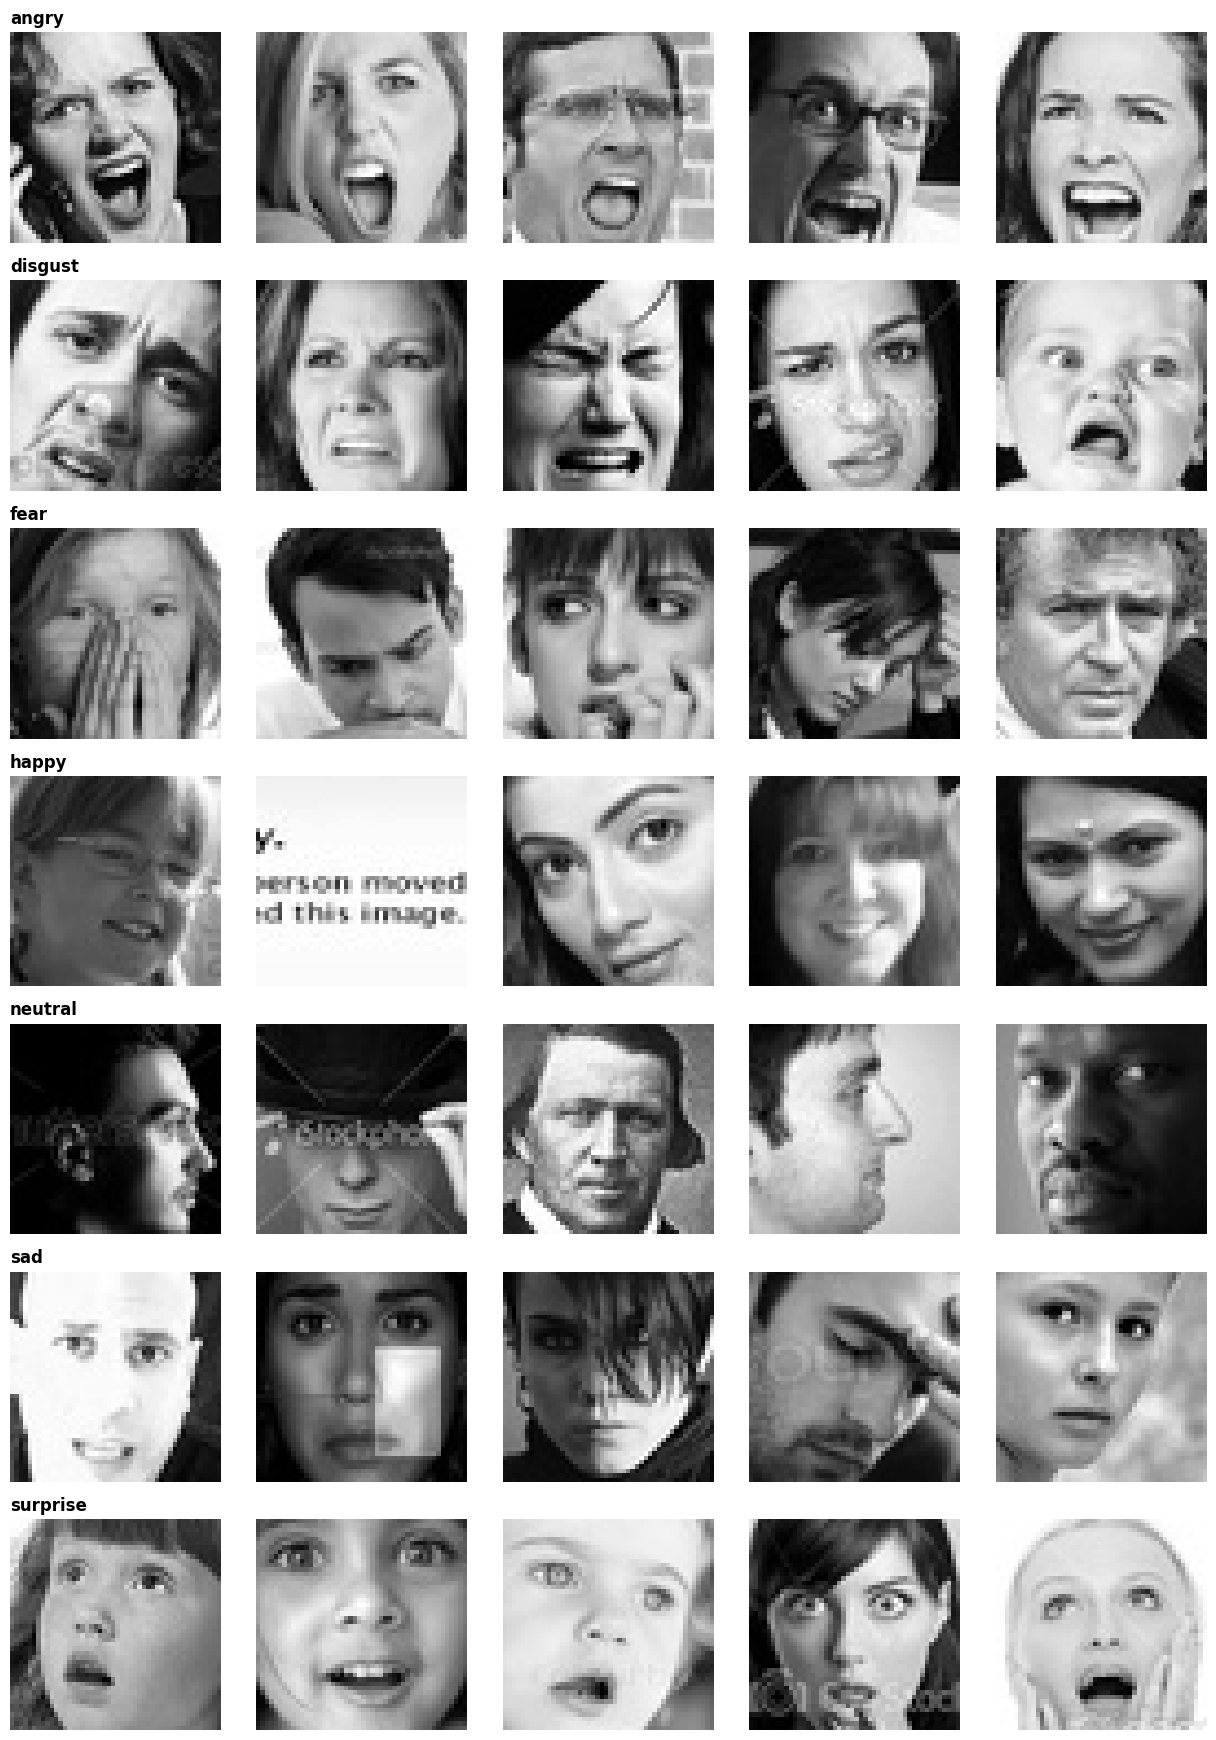

In [9]:
preview_fig

https://arxiv.org/pdf/1307.0414 (rapport om tävlingen som fick FER-2013 att uppstå)

FER-2013 togs fram i samband med en maskininlärningstävling 2013. Datasetet skapades genom att använda Google Image Search API med 184 känslorelaterade sökord, som sedan kategeoriserades i sju känsloklasser: 

- angry
- disgust
- fear
- happy
- sad
- surpries 
- neutral

Jag vill säga att detta i kombination med att tolkning av känslouttryck är subjektivt gör FER-2013 till ett svårt dataset för min NN-modell att sätta tänderna i... 

Bara i dessa 35 slumpmässiga bilder finns det brus som gör det svårt: 

- flera bilder innehåller text
- en bild hann försvinna
- varje rad innehåller minst en bild som mycket väl skulle kunna passa i en eller flera andra klasser  

## 2. Förbehandling

### 2.1 Dela upp datan i train och val

In [10]:
def create_image_df(directory_path, class_list):
    """
    Skannar en mapp och returnerar en DataFrame med bildvägar och etiketter.
    """
    all_data = []
    for cls in class_list:
        cls_dir = directory_path / cls
        if cls_dir.is_dir():
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
                    all_data.append({
                        "path": img_path,
                        "label": cls
                    })
    
    return pd.DataFrame(all_data)

In [11]:
base_dir = Path("data/train")
classes = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

df = create_image_df(base_dir, classes)

In [12]:
sampled_dfs = []
for cls in classes:
    cls_df = df[df["label"] == cls]
    if len(cls_df) >= 3000:
        cls_sampled = cls_df.sample(n=3000, random_state=42) # Hur säkerställer jag att allt random blir samma hela tiden? 
    else:
        cls_sampled = cls_df
    sampled_dfs.append(cls_sampled)

main_df = pd.concat(sampled_dfs).reset_index(drop=True)

In [13]:
train_df_all, val_df_all = train_test_split(
    main_df,
    test_size=0.2,
    stratify=main_df["label"],
    random_state=42
)

In [14]:
binary_classes = ["happy", "sad"]
train_df_binary = train_df_all[train_df_all["label"].isin(binary_classes)]
val_df_binary = val_df_all[val_df_all["label"].isin(binary_classes)]

In [15]:
def load_images_from_df(df, label_mapping):
    """
    Laddar bilder från DataFrames.
    """
    X = []
    y = []

    for idx, row in df.iterrows():
        img_path_str = str(row["path"])
        img = cv2.imread(img_path_str, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            X.append(img)
            y.append(label_mapping[row["label"]])

    return np.array(X), np.array(y)

In [16]:
multiclass_mapping = {cls: idx for idx, cls in enumerate(classes)}
binary_mapping = {"happy": 0, "sad": 1}

In [17]:
X_train_m1, y_train_m1 = load_images_from_df(train_df_binary, binary_mapping)
X_val_m1, y_val_m1 = load_images_from_df(val_df_binary, binary_mapping)

X_train_m2, y_train_m2 = load_images_from_df(train_df_all, multiclass_mapping)
X_val_m2, y_val_m2 = load_images_from_df(val_df_all, multiclass_mapping)

In [18]:
# Kontrollerar shape
print("--- MODELL 1 (Binär: Happy & Sad) ---")
print(f"X_train_m1 shape: {X_train_m1.shape}  (Förväntat: (4800, 48, 48))")
print(f"X_val_m1   shape: {X_val_m1.shape}   (Förväntat: (1200, 48, 48))")

print("\n--- MODELL 2 (Multiclass: Alla 7) ---")
print(f"X_train_m2 shape: {X_train_m2.shape} (Förväntat: runt (14748, 48, 48))")
print(f"X_val_m2   shape: {X_val_m2.shape}  (Förväntat: runt (3688, 48, 48))")

--- MODELL 1 (Binär: Happy & Sad) ---
X_train_m1 shape: (4800, 48, 48)  (Förväntat: (4800, 48, 48))
X_val_m1   shape: (1200, 48, 48)   (Förväntat: (1200, 48, 48))

--- MODELL 2 (Multiclass: Alla 7) ---
X_train_m2 shape: (14748, 48, 48) (Förväntat: runt (14748, 48, 48))
X_val_m2   shape: (3688, 48, 48)  (Förväntat: runt (3688, 48, 48))


In [19]:
# Kontrollerar klassfördelningen
print("Modell 1 - Fördelning i träningsdatan (ska vara 2400 per klass):")
# Index 0 = happy, Index 1 = sad
print(f"Happy: {np.bincount(y_train_m1)[0]}, Sad: {np.bincount(y_train_m1)[1]}")

print("\nModell 1 - Fördelning i valideringsdatan (ska vara 600 per klass):")
print(f"Happy: {np.bincount(y_val_m1)[0]}, Sad: {np.bincount(y_val_m1)[1]}")

print("\nModell 2 - Fördelning per klass i träningsdatan:")
for cls, idx in multiclass_mapping.items():
    print(f"Klass {idx} ({cls}): {np.bincount(y_train_m2)[idx]} bilder")

print("\nModell 2 - Fördelning per klass i valideringssdatan:")
for cls, idx in multiclass_mapping.items():
    print(f"Klass {idx} ({cls}): {np.bincount(y_val_m2)[idx]} bilder")

Modell 1 - Fördelning i träningsdatan (ska vara 2400 per klass):
Happy: 2400, Sad: 2400

Modell 1 - Fördelning i valideringsdatan (ska vara 600 per klass):
Happy: 600, Sad: 600

Modell 2 - Fördelning per klass i träningsdatan:
Klass 0 (angry): 2400 bilder
Klass 1 (disgust): 348 bilder
Klass 2 (fear): 2400 bilder
Klass 3 (happy): 2400 bilder
Klass 4 (neutral): 2400 bilder
Klass 5 (sad): 2400 bilder
Klass 6 (surprise): 2400 bilder

Modell 2 - Fördelning per klass i valideringssdatan:
Klass 0 (angry): 600 bilder
Klass 1 (disgust): 88 bilder
Klass 2 (fear): 600 bilder
Klass 3 (happy): 600 bilder
Klass 4 (neutral): 600 bilder
Klass 5 (sad): 600 bilder
Klass 6 (surprise): 600 bilder


In [20]:
inverse_binary_mapping = {v: k for k, v in binary_mapping.items()}
inverse_multiclass_mapping = {v: k for k, v in multiclass_mapping.items()}

def find_indices_per_class(y_array, num_classes):
    """
    Hittar det första indexet i en y-array för varje klass.
    """
    indices_per_class = {}
    for label_siffra in range(num_classes):
        all_indices = np.where(y_array == label_siffra)[0]
        if len(all_indices) > 0:
            indices_per_class[label_siffra] = all_indices[0]
    return indices_per_class

In [21]:
# Skapar funktion för att plotta bilder i ett rutnät
def plot_images_grid(X_array, indices_dict, inverse_mapping, title, num_classes):
    """
    Plottar en bild från varje klass i ett rutnät.
    """
    cols = 2 if num_classes == 2 else 4
    rows = (num_classes + cols - 1) // cols 

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(title, fontsize=16)
    
    axes_flat = axes.flatten() if num_classes > 1 else [axes]

    for label_siffra, idx in indices_dict.items():
        if label_siffra < len(axes_flat):
            ax = axes_flat[label_siffra]
            ax.imshow(X_array[idx], cmap="gray")
            
            label_text = inverse_mapping[label_siffra]
            ax.set_title(f"{label_text} ({label_siffra})", fontsize=12)
            ax.axis("off")
            
    for i in range(len(indices_dict), len(axes_flat)):
        axes_flat[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()

--- Kontroll av Modell 1 (Happy & Sad) ---


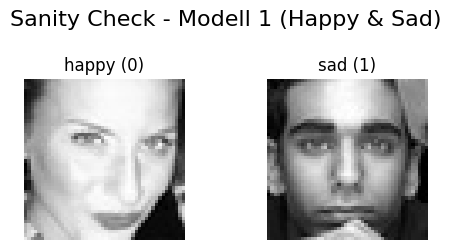

In [22]:
print("--- Kontroll av Modell 1 (Happy & Sad) ---")
indices_m1 = find_indices_per_class(y_train_m1, num_classes=2)

plot_images_grid(
    X_train_m1, 
    indices_m1, 
    inverse_binary_mapping, 
    "Sanity Check - Modell 1 (Happy & Sad)",
    num_classes=2
)

--- Kontroll av Modell 2 (Alla 7 Klasser) ---


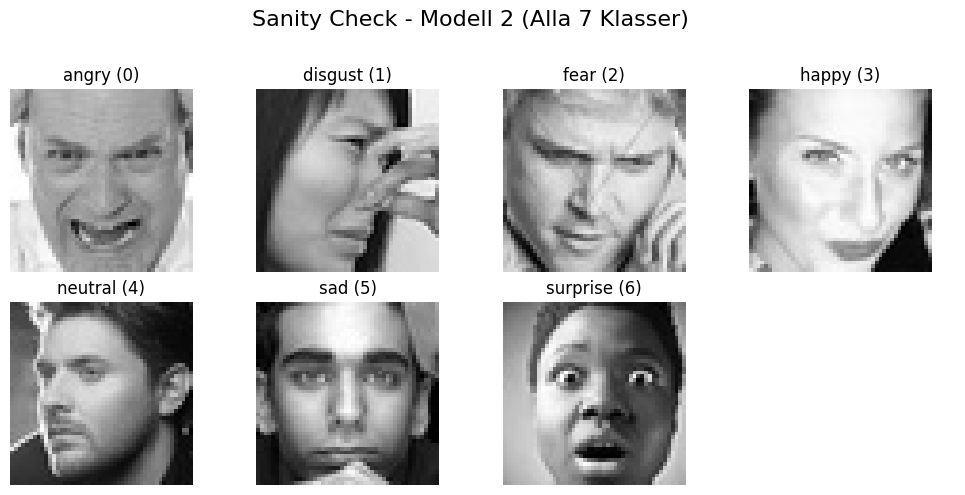

In [23]:
print("--- Kontroll av Modell 2 (Alla 7 Klasser) ---")
# Vi använder len(classes) för att dynamiskt räkna ut antal klasser (7)
num_all_classes = len(classes)
indices_m2 = find_indices_per_class(y_train_m2, num_classes=num_all_classes)

plot_images_grid(
    X_train_m2, 
    indices_m2, 
    inverse_multiclass_mapping, 
    "Sanity Check - Modell 2 (Alla 7 Klasser)",
    num_classes=num_all_classes
)

### 2.2 Testdatan

In [24]:
base_test_dir = Path("data/test")

test_df_all = create_image_df(base_test_dir, classes)

test_df_binary = test_df_all[test_df_all["label"].isin(binary_classes)]

In [25]:
X_test_m1, y_test_m1 = load_images_from_df(test_df_binary, binary_mapping)

X_test_m2, y_test_m2 = load_images_from_df(test_df_all, multiclass_mapping)

In [26]:
print("--- VERIFIERING AV TESTDATA ---")
print(f"Modell 1 (Happy/Sad) - X_test: {X_test_m1.shape}, y_test: {y_test_m1.shape}")
print(f"Modell 2 (Alla 7)    - X_test: {X_test_m2.shape}, y_test: {y_test_m2.shape}")

--- VERIFIERING AV TESTDATA ---
Modell 1 (Happy/Sad) - X_test: (3021, 48, 48), y_test: (3021,)
Modell 2 (Alla 7)    - X_test: (7178, 48, 48), y_test: (7178,)


### 2.3 Skala datan

In [27]:
# Skala bilderna till 0-1
X_train_m1_scaled = X_train_m1 / 255.0
X_val_m1_scaled = X_val_m1 / 255.0
X_test_m1_scaled = X_test_m1 / 255.0

# Lägg till färgkanalen längst bak (axis=-1)
X_train_m1_scaled = np.expand_dims(X_train_m1_scaled, axis=-1)
X_val_m1_scaled = np.expand_dims(X_val_m1_scaled, axis=-1)
X_test_m1_scaled = np.expand_dims(X_test_m1_scaled, axis=-1)

# Kontrollera formen
print(f"Data till modell 1 klar för träning! Form: {X_train_m1_scaled.shape}")
# Ska visa: (4800, 48, 48, 1)

Data till modell 1 klar för träning! Form: (4800, 48, 48, 1)


In [28]:
# Skala bilderna till 0-1
X_train_m2_scaled = X_train_m2 / 255.0
X_val_m2_scaled = X_val_m2 / 255.0
X_test_m2_scaled = X_test_m2 / 255.0

# Lägg till färgkanalen längst bak
X_train_m2_scaled = np.expand_dims(X_train_m2_scaled, axis=-1)
X_val_m2_scaled = np.expand_dims(X_val_m2_scaled, axis=-1)
X_test_m2_scaled = np.expand_dims(X_test_m2_scaled, axis=-1)

# Kontrollera formen
print(f"Data till modell 2+ klar för träning! Form: {X_train_m2_scaled.shape}")
# Ska visa: (runt 14748, 48, 48, 1)

Data till modell 2+ klar för träning! Form: (14748, 48, 48, 1)


## 3. Modellering och experiment

### Hjälpfunktioner

In [29]:
def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### 3.1 Modell 1 - börja smått

#### Den allra första modellen

In [ ]:
# Bygger en allra första modell 
model_1_1 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(2, activation="softmax")
])

# Kompilera
model_1_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [31]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_1 = model_1_1.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5492 - loss: 0.6858 - val_accuracy: 0.6267 - val_loss: 0.6437
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6787 - loss: 0.6030 - val_accuracy: 0.7200 - val_loss: 0.5458
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7425 - loss: 0.5294 - val_accuracy: 0.7525 - val_loss: 0.5097
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7660 - loss: 0.4790 - val_accuracy: 0.7633 - val_loss: 0.4862
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7937 - loss: 0.4356 - val_accuracy: 0.7742 - val_loss: 0.4678
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8177 - loss: 0.3936 - val_accuracy: 0.7725 - val_loss: 0.4675
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8410 - loss: 0.3464 - val_accuracy: 0.7775 - val_loss: 0.4689
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8681 - loss: 0.3013 - val_accuracy: 0.

#### Träningskurvor, den allra första modellen

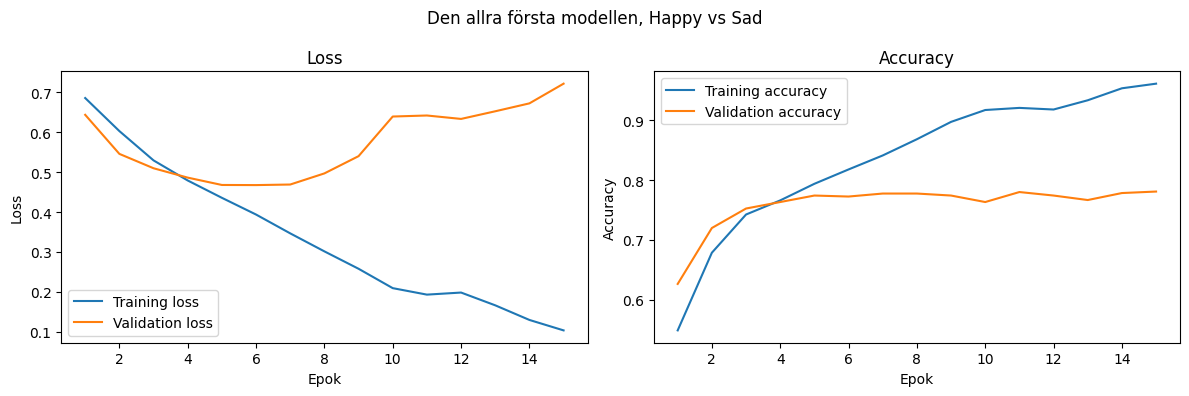

In [32]:
plot_history(history_1_1, title="Den allra första modellen, Happy vs Sad")

#### Förbättra modellen, steg 1

In [33]:
# Bygger en förbättrad modell, lägger till ett dropout-lager 
model_1_2 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

# Kompilera
model_1_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [34]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_2 = model_1_2.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5702 - loss: 0.6790 - val_accuracy: 0.6433 - val_loss: 0.6301
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6798 - loss: 0.6075 - val_accuracy: 0.7358 - val_loss: 0.5363
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7360 - loss: 0.5287 - val_accuracy: 0.7650 - val_loss: 0.4878
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7642 - loss: 0.4824 - val_accuracy: 0.7733 - val_loss: 0.4554
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7900 - loss: 0.4380 - val_accuracy: 0.7975 - val_loss: 0.4401
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8125 - loss: 0.3995 - val_accuracy: 0.7908 - val_loss: 0.4428
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8329 - loss: 0.3711 - val_accuracy: 0.7892 - val_loss: 0.4408
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8506 - loss: 0.3327 - val_accuracy: 0.

#### Träningskurvor, den förbättrade modellen

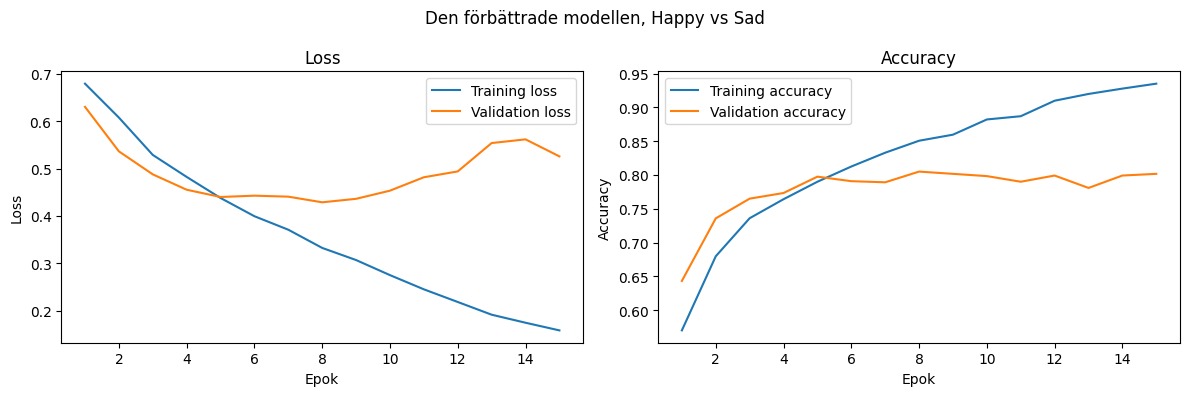

In [35]:
plot_history(history_1_2, title="Den förbättrade modellen, Happy vs Sad")

#### Förbättra modellen, steg 2

In [ ]:
# Bygger en förbättrad modell 
model_1_3 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

# Kompilera
model_1_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [37]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_3 = model_1_3.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5475 - loss: 0.6895 - val_accuracy: 0.6483 - val_loss: 0.6378
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6433 - loss: 0.6344 - val_accuracy: 0.7125 - val_loss: 0.5642
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7090 - loss: 0.5656 - val_accuracy: 0.7383 - val_loss: 0.5225
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7392 - loss: 0.5226 - val_accuracy: 0.7575 - val_loss: 0.4979
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7748 - loss: 0.4741 - val_accuracy: 0.7683 - val_loss: 0.4772
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7852 - loss: 0.4378 - val_accuracy: 0.7642 - val_loss: 0.4703
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8079 - loss: 0.4050 - val_accuracy: 0.7692 - val_loss: 0.4608
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8254 - loss: 0.3686 - val_accuracy: 0.

#### Träningskurvor, den förbättrade modellen med Early Stopping

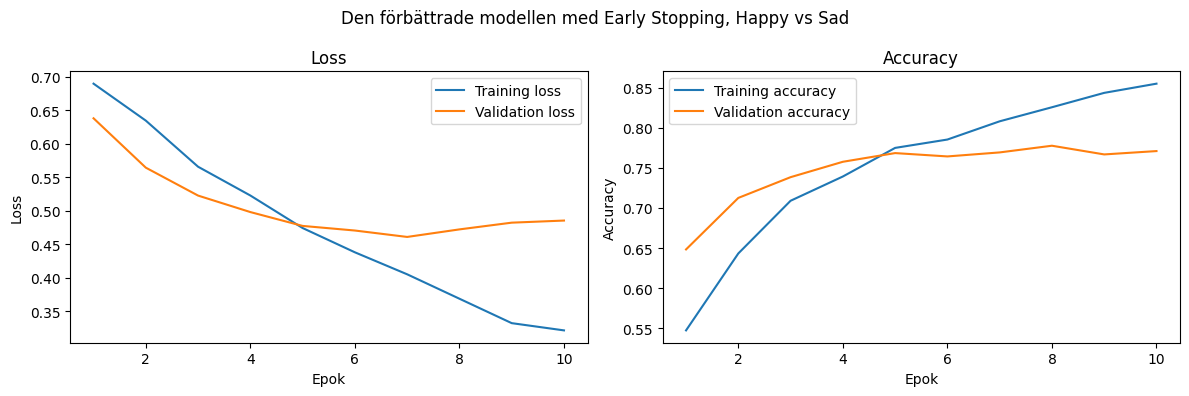

In [38]:
plot_history(history_1_3, title="Den förbättrade modellen med Early Stopping, Happy vs Sad")

#### Confusion Matrix, den förbättrade modellen

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


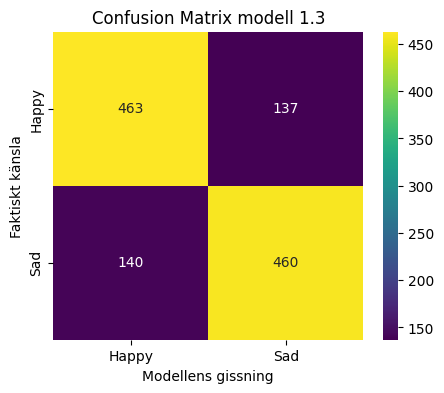

In [39]:
y_pred_probs = model_1_3.predict(X_val_m1_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_val_m1, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=["Happy", "Sad"],
            yticklabels=["Happy", "Sad"])
plt.ylabel("Faktiskt känsla")
plt.xlabel("Modellens gissning")
plt.title("Confusion Matrix modell 1.3")
plt.show()

#### Exempel på bilder där modellen gissade rätt, och där den gissade fel

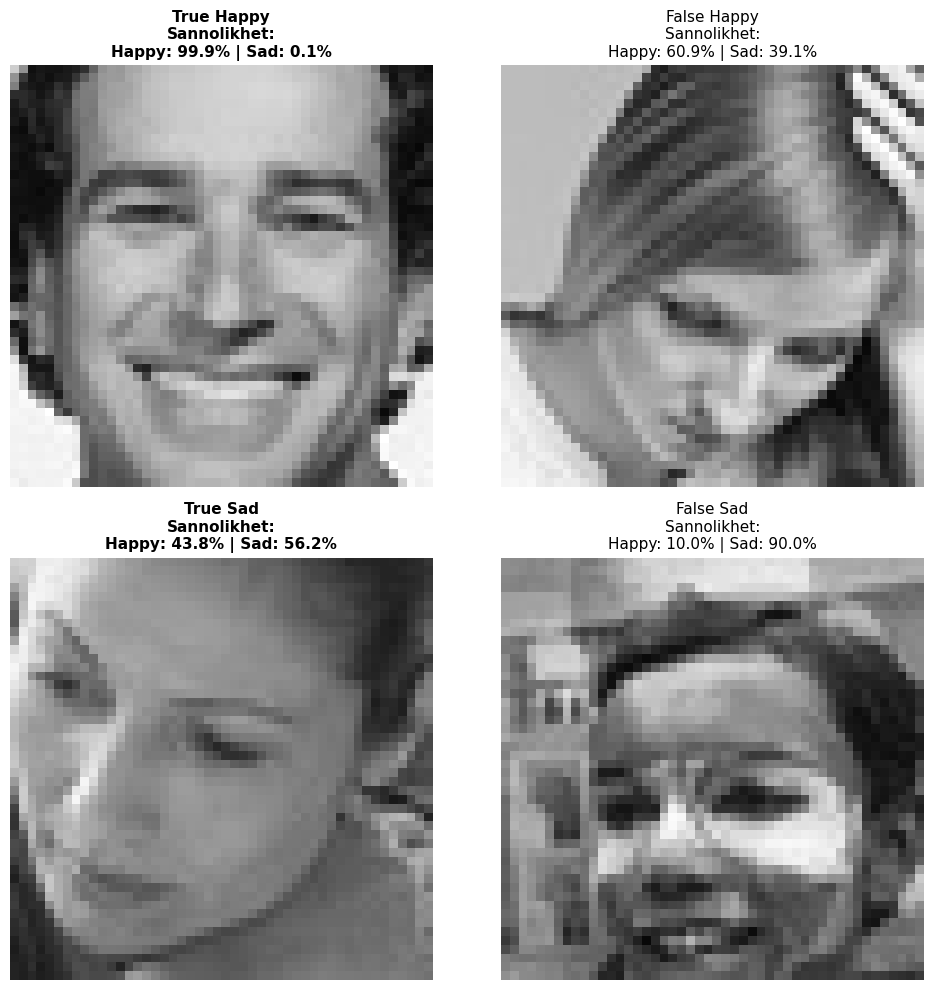

In [40]:
# Definiera index för de fyra olika scenarierna 
scenarios = {
    "True Happy": (y_val_m1 == 0) & (y_pred == 0),
    "False Happy": (y_val_m1 == 1) & (y_pred == 0),
    "True Sad": (y_val_m1 == 1) & (y_pred == 1),
    "False Sad": (y_val_m1 == 0) & (y_pred == 1)
}

# Skapar en figur med 2 rader och 2 kolumner 
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, (title, mask) in enumerate(scenarios.items()):
    axes[i].axis("off")
    matching_indices = np.where(mask)[0]

    if len(matching_indices) > 0:
        idx = matching_indices[0]
        img = X_val_m1_scaled[idx].squeeze()

        prob_happy = y_pred_probs[idx][0] * 100
        prob_sad = y_pred_probs[idx][1] * 100

        axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)

        axes[i].set_title(
            f"{title}\n"
            f"Sannolikhet:\n"
            f"Happy: {prob_happy:.1f}% | Sad: {prob_sad:.1f}%",
            fontsize=11,
            fontweight="bold" if "True" in title else "normal"
        )
    
    else:
        axes[i].text(0.5, 0.5, f"Inga exempel hittades för :\n{title}",
                     ha="center", va="center")
        axes[i].axis("off")

plt.tight_layout()
plt.show()

#### Sammanställning Modell 1

In [41]:
def get_epoch_data(history_obj, model_name, mode="last"):
    hist = history_obj.history
    total_epochs = len(hist["loss"])

    if mode == "best":
        target_index = np.argmin(hist["val_loss"])
    else:
        target_index = total_epochs - 1

    return {
        "Modell": model_name,
        "Totala epoker": total_epochs,
        "Utvärderad epok": target_index + 1,
        "Training Loss": hist["loss"][target_index],
        "Training Accuracy": hist["accuracy"][target_index],
        "Val Loss": hist["val_loss"][target_index],
        "Val Accuracy": hist["val_accuracy"][target_index]
    }

table_data = [
    get_epoch_data(history_1_1, "Modell 1.1 Baseline", mode="last"),
    get_epoch_data(history_1_2, "Modell 1.2 + Dropout", mode="last"),
    get_epoch_data(history_1_3, "Modell 1.3 + Dropout + Early Stopping", mode="best")
]

summary_df = pd.DataFrame(table_data)

summary_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
})

,Modell,Totala epoker,Utvärderad epok,Training Loss,Training Accuracy,Val Loss,Val Accuracy
0,Modell 1.1 Baseline,15,15,0.1031,96.08%,0.7218,78.08%
1,Modell 1.2 + Dropout,15,15,0.1589,93.50%,0.5257,80.17%
2,Modell 1.3 + Dropout + Early Stopping,10,7,0.4050,80.79%,0.4608,76.92%


### 3.2 Modell 2 - déjà vu

#### Transfer Learning

In [42]:
base_model = keras.models.clone_model(model_1_3)
base_model.set_weights(model_1_3.get_weights())

#### Modell 2.1

In [43]:
model_2_1 = models.Sequential([
    *base_model.layers[:-1],
    layers.Dense(7, activation="softmax", name="new_classification_layer")
])

for layer in model_2_1.layers[:-1]:
    layer.trainable = False

model_2_1.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model_2_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_classification_layer        │ ?                      │   0 (unbuilt) │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,198,592 (4.57 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,198,592 (4.57 MB)

In [44]:
start_time = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_2_1 = model_2_1.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=15,
    batch_size=32,
    # callbacks=[early_stopping]
)

end_time = time.time()

training_time_2_1 = end_time - start_time

print(f"Träningstid: {training_time_2_1}s")

Epoch 1/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2273 - loss: 1.8324 - val_accuracy: 0.2698 - val_loss: 1.7597
Epoch 2/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2813 - loss: 1.7354 - val_accuracy: 0.2842 - val_loss: 1.7477
Epoch 3/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2928 - loss: 1.7231 - val_accuracy: 0.2888 - val_loss: 1.7417
Epoch 4/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2983 - loss: 1.7115 - val_accuracy: 0.2931 - val_loss: 1.7367
Epoch 5/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3021 - loss: 1.7106 - val_accuracy: 0.2901 - val_loss: 1.7340
Epoch 6/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3038 - loss: 1.7069 - val_accuracy: 0.2934 - val_loss: 1.7322
Epoch 7/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3049 - loss: 1.7022 - val_accuracy: 0.2961 - val_loss: 1.7296
Epoch 8/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3051 - loss: 1.7027 - val_accuracy: 0.

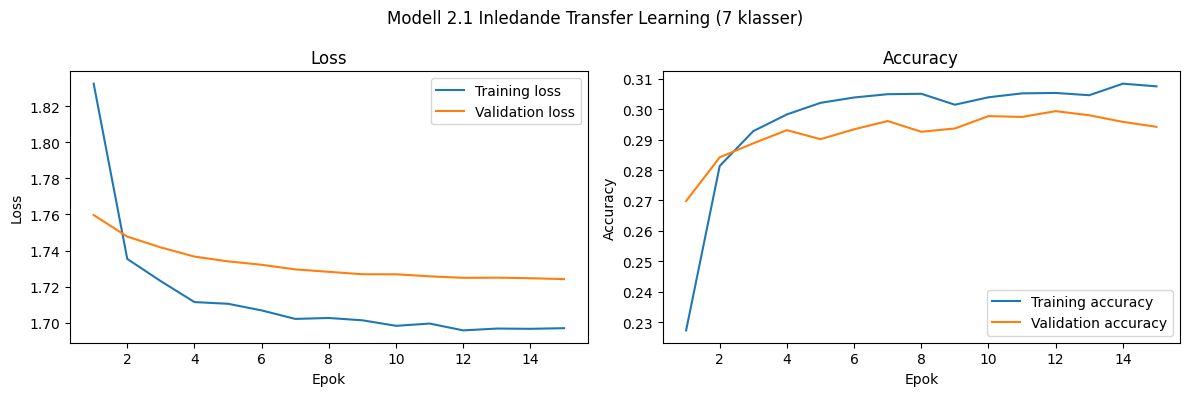

In [45]:
plot_history(history_2_1, title="Modell 2.1 Inledande Transfer Learning (7 klasser)")

#### Modell 2.2

In [46]:
model_2_2 = model_2_1

model_2_2.trainable = True

for i, layer in enumerate(model_2_2.layers):
    if i in [0, 1]:
        layer.trainable = False
    else:
        layer.trainable = True

model_2_2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_classification_layer        │ (None, 7)              │           903 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,175 (4.57 MB)

 Non-trainable params: 320 (1.25 KB)

In [47]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
start_time = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_2_2 = model_2_2.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=15,
    batch_size=32,
    # callbacks=[early_stopping]
)

end_time = time.time()

training_time_2_2 = end_time - start_time

print(f"Träningstid: {training_time_2_2}s")

Epoch 1/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3076 - loss: 1.6915 - val_accuracy: 0.3021 - val_loss: 1.7162
Epoch 2/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3146 - loss: 1.6886 - val_accuracy: 0.3107 - val_loss: 1.7092
Epoch 3/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3198 - loss: 1.6794 - val_accuracy: 0.3172 - val_loss: 1.7012
Epoch 4/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3261 - loss: 1.6663 - val_accuracy: 0.3240 - val_loss: 1.6945
Epoch 5/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3345 - loss: 1.6575 - val_accuracy: 0.3294 - val_loss: 1.6889
Epoch 6/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3312 - loss: 1.6591 - val_accuracy: 0.3313 - val_loss: 1.6835
Epoch 7/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3366 - loss: 1.6496 - val_accuracy: 0.3335 - val_loss: 1.6788
Epoch 8/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3400 - loss: 1.6450 - val_accuracy: 0.

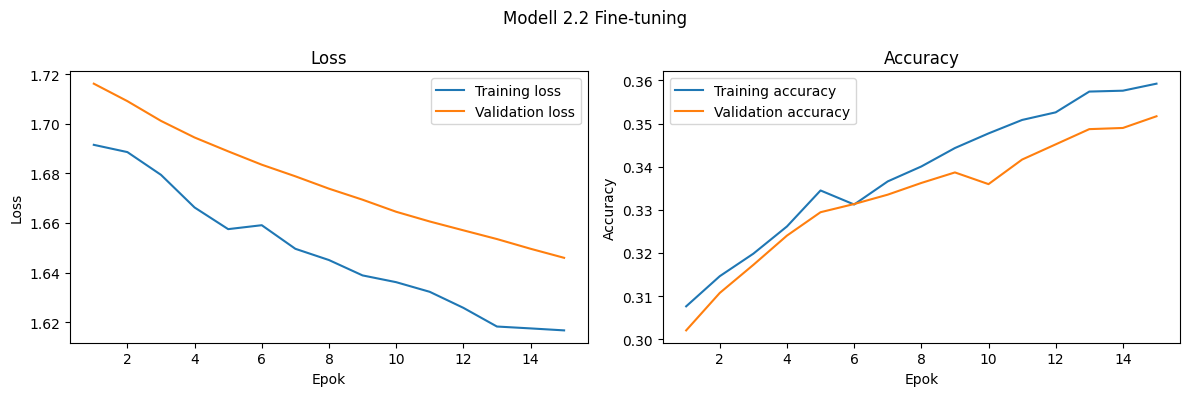

In [48]:
plot_history(history_2_2, title="Modell 2.2 Fine-tuning")

#### Modell 2.3

In [49]:
model_2_3 = model_2_2

for layer in model_2_3.layers:
    layer.trainable = True

In [50]:
model_2_3.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ new_classification_layer        │ (None, 7)              │           903 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
start_time = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_2_3 = model_2_3.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=15,
    batch_size=32,
    # callbacks=[early_stopping]
)

end_time = time.time()

training_time_2_3 = end_time - start_time

print(f"Träningstid: {training_time_2_3}s")

Epoch 1/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3623 - loss: 1.6084 - val_accuracy: 0.3530 - val_loss: 1.6426
Epoch 2/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3691 - loss: 1.6032 - val_accuracy: 0.3552 - val_loss: 1.6390
Epoch 3/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3645 - loss: 1.5996 - val_accuracy: 0.3576 - val_loss: 1.6353
Epoch 4/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3635 - loss: 1.6013 - val_accuracy: 0.3560 - val_loss: 1.6331
Epoch 5/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3674 - loss: 1.5982 - val_accuracy: 0.3595 - val_loss: 1.6296
Epoch 6/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3704 - loss: 1.5911 - val_accuracy: 0.3590 - val_loss: 1.6269
Epoch 7/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3720 - loss: 1.5842 - val_accuracy: 0.3590 - val_loss: 1.6241
Epoch 8/15
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3732 - loss: 1.5843 - val_accuracy: 0.

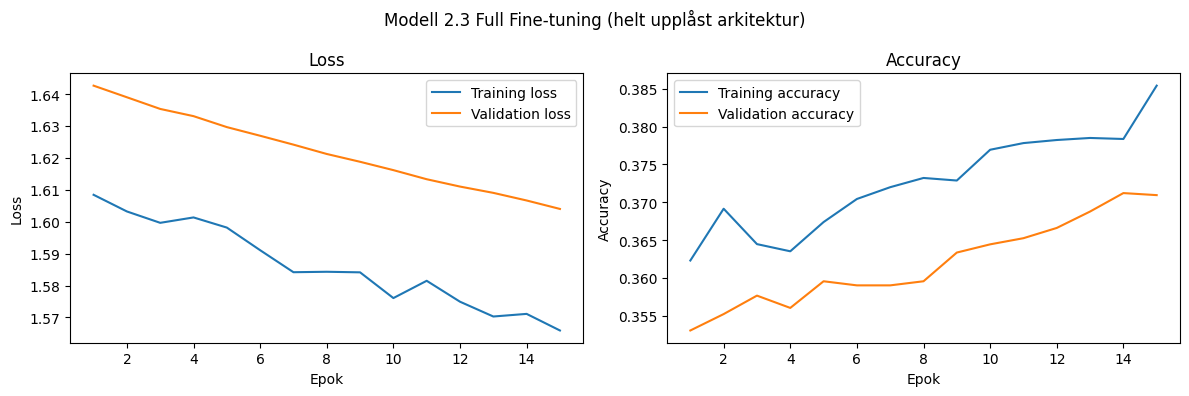

In [52]:
plot_history(history_2_3, title="Modell 2.3 Full Fine-tuning (helt upplåst arkitektur)")

#### Sammanställning modell 2

In [53]:
# En hjälpfunktion för att göra sekunder till minuter och sekunder
def format_time(seconds):
    mins, secs = divmod(seconds, 60)
    return f"{int(mins)}m {int(secs)}s"

table_data_m2 = [
    {
        "Modell": "Modell 2.1 (Feature Extraction)",
        "Training Loss": history_2_1.history["loss"][-1],
        "Training Accuracy": history_2_1.history["accuracy"][-1],
        "Val Loss": history_2_1.history["val_loss"][-1],
        "Val Accuracy": history_2_1.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_1) 
    },
    {
        "Modell": "Modell 2.2 (Partial Fine-tuning)",
        "Training Loss": history_2_2.history["loss"][-1],
        "Training Accuracy": history_2_2.history["accuracy"][-1],
        "Val Loss": history_2_2.history["val_loss"][-1],
        "Val Accuracy": history_2_2.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_2) 
    },
    {
        "Modell": "Modell 2.3 (Full Fine-tuning)",
        "Training Loss": history_2_3.history["loss"][-1],
        "Training Accuracy": history_2_3.history["accuracy"][-1],
        "Val Loss": history_2_3.history["val_loss"][-1],
        "Val Accuracy": history_2_3.history["val_accuracy"][-1],
        "Träningstid": format_time(training_time_2_3) 
    }
]

# Skapa en DataFrame
summary_m2_df = pd.DataFrame(table_data_m2)

summary_m2_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
}).hide(axis="index")

Modell,Training Loss,Training Accuracy,Val Loss,Val Accuracy,Träningstid
Modell 2.1 (Feature Extraction),1.6971,30.75%,1.7242,29.42%,0m 21s
Modell 2.2 (Partial Fine-tuning),1.6166,35.92%,1.6459,35.17%,0m 46s
Modell 2.3 (Full Fine-tuning),1.5659,38.54%,1.6040,37.09%,0m 59s


### 3.3 Modell 3 - stå på egna ben

In [54]:
base_clone = keras.models.clone_model(model_1_3)

model_3 = keras.Sequential(base_clone.layers[:-1])

model_3.add(keras.layers.Dense(7, activation="softmax", name="output_scratch"))

model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_scratch (Dense)          │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,198,592 (4.57 MB)

 Trainable params: 1,198,592 (4.57 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
start_time = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_3 = model_3.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    # callbacks=[early_stopping]
)

end_time = time.time()

training_time_3 = end_time - start_time

print(f"Träningstid: {training_time_3}s")

Epoch 1/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2613 - loss: 1.7784 - val_accuracy: 0.3471 - val_loss: 1.6651
Epoch 2/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3561 - loss: 1.6213 - val_accuracy: 0.4056 - val_loss: 1.5352
Epoch 3/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4120 - loss: 1.5186 - val_accuracy: 0.4279 - val_loss: 1.4775
Epoch 4/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4436 - loss: 1.4339 - val_accuracy: 0.4509 - val_loss: 1.4231
Epoch 5/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4708 - loss: 1.3691 - val_accuracy: 0.4566 - val_loss: 1.4049
Epoch 6/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5047 - loss: 1.2973 - val_accuracy: 0.4574 - val_loss: 1.3956
Epoch 7/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5254 - loss: 1.2358 - val_accuracy: 0.4561 - val_loss: 1.3985
Epoch 8/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5519 - loss: 1.1685 - val_accuracy: 0.

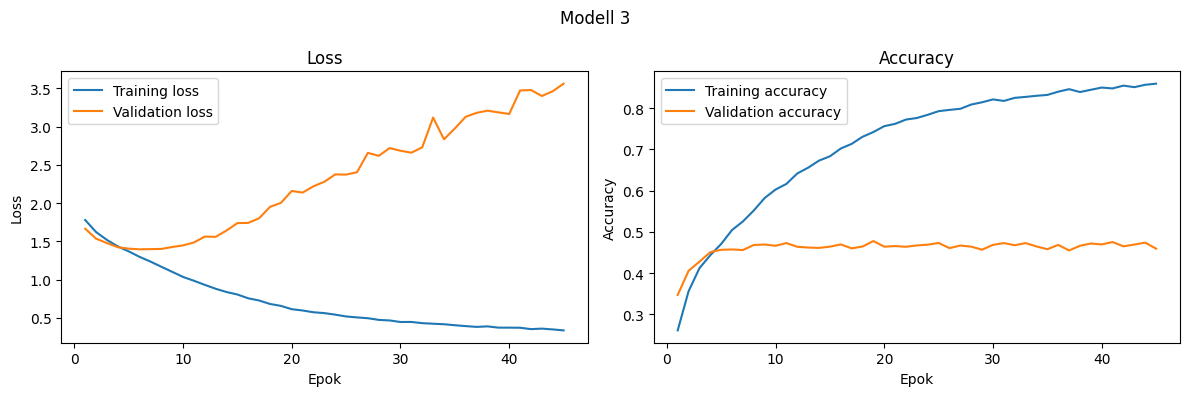

In [56]:
plot_history(history_3, title="Modell 3")

#### Sammanställning

In [ ]:
# Hitta automatiskt indexet för lägsta val_loss i Modell 3
best_idx_m3 = np.argmin(history_3.history["val_loss"])
best_epoch_m3 = best_idx_m3 + 1 

# Beräkna den ackumulerade tiden fram till de olika milstolparna
time_m3_at_15 = training_time_3 / 3
time_m3_at_30 = (training_time_3 / 3) * 2
time_m3_at_45 = training_time_3

# Tid fram till den bästa epoken (baserat på genomsnittlig tid per epok)
time_m3_at_best = (training_time_3 / 45) * best_epoch_m3

final_table_data = [
    {
        "Modell": "Modell 2.1 (Feature Extraction)",
        "Training Loss": history_2_1.history["loss"][-1],
        "Training Accuracy": history_2_1.history["accuracy"][-1],
        "Val Loss": history_2_1.history["val_loss"][-1],
        "Val Accuracy": history_2_1.history["val_accuracy"][-1],
        "Träningstid (Ackumulerad)": format_time(training_time_2_1)
    },
    {
        "Modell": "Modell 2.2 (Partial Fine-tuning)",
        "Training Loss": history_2_2.history["loss"][-1],
        "Training Accuracy": history_2_2.history["accuracy"][-1],
        "Val Loss": history_2_2.history["val_loss"][-1],
        "Val Accuracy": history_2_2.history["val_accuracy"][-1],
        "Träningstid (Ackumulerad)": format_time(training_time_2_2)
    },
    {
        "Modell": "Modell 2.3 (Full Fine-tuning)",
        "Training Loss": history_2_3.history["loss"][-1],
        "Training Accuracy": history_2_3.history["accuracy"][-1],
        "Val Loss": history_2_3.history["val_loss"][-1],
        "Val Accuracy": history_2_3.history["val_accuracy"][-1],
        "Träningstid (Ackumulerad)": format_time(training_time_2_3)
    },
    {
        "Modell": "Modell 3 (Milstolpe Epok 15)",
        "Training Loss": history_3.history["loss"][14],
        "Training Accuracy": history_3.history["accuracy"][14],
        "Val Loss": history_3.history["val_loss"][14],
        "Val Accuracy": history_3.history["val_accuracy"][14],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_15)
    },
    {
        "Modell": "Modell 3 (Milstolpe Epok 30)",
        "Training Loss": history_3.history["loss"][29],
        "Training Accuracy": history_3.history["accuracy"][29],
        "Val Loss": history_3.history["val_loss"][29],
        "Val Accuracy": history_3.history["val_accuracy"][29],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_30)
    },
    {
        "Modell": "Modell 3 (Slutresultat Epok 45)",
        "Training Loss": history_3.history["loss"][44],
        "Training Accuracy": history_3.history["accuracy"][44],
        "Val Loss": history_3.history["val_loss"][44],
        "Val Accuracy": history_3.history["val_accuracy"][44],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_45)
    },
    {
        "Modell": f"Modell 3 (Optimal Epok {best_epoch_m3})",
        "Training Loss": history_3.history["loss"][best_idx_m3],
        "Training Accuracy": history_3.history["accuracy"][best_idx_m3],
        "Val Loss": history_3.history["val_loss"][best_idx_m3],
        "Val Accuracy": history_3.history["val_accuracy"][best_idx_m3],
        "Träningstid (Ackumulerad)": format_time(time_m3_at_best)
    }
]

# Skapa och formatera DataFrame
final_summary_df = pd.DataFrame(final_table_data)

final_summary_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
}).hide(axis="index")

Modell,Training Loss,Training Accuracy,Val Loss,Val Accuracy,Träningstid (Ackumulerad)
Modell 2.1 (Feature Extraction),1.6971,30.75%,1.7242,29.42%,0m 21s
Modell 2.2 (Partial Fine-tuning),1.6166,35.92%,1.6459,35.17%,0m 46s
Modell 2.3 (Full Fine-tuning),1.5659,38.54%,1.6040,37.09%,0m 59s
Modell 3 (Milstolpe Epok 15),0.8055,68.32%,1.7384,46.42%,0m 59s
Modell 3 (Milstolpe Epok 30),0.4465,82.11%,2.6833,46.85%,1m 58s
Modell 3 (Slutresultat Epok 45),0.3369,85.93%,3.5597,45.93%,2m 57s
Modell 3 (Optimal Epok 6),1.2973,50.47%,1.3956,45.74%,0m 23s


### 3.4 Modell 4 - basmodell inför klasskamp

In [60]:
model_4_1 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [61]:
model_4_1.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [62]:
print("Startar träning av Modell 4.1 (Max 45 epoker med Early Stopping)")
start_time_4_1 = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_4_1 = model_4_1.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    callbacks=[early_stopping]
)

training_time_4_1 = time.time() - start_time_4_1
m41_mins, m41_secs = divmod(training_time_4_1, 60)
print(f"\nTräning avbruten/klar via Early Stopping")
print(f"Total träningstid: {int(m41_mins)}m {int(m41_secs)}s")

Startar träning av Modell 4.1 (Max 45 epoker med Early Stopping)
Epoch 1/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2126 - loss: 1.8337 - val_accuracy: 0.2972 - val_loss: 1.7197
Epoch 2/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3190 - loss: 1.6972 - val_accuracy: 0.3590 - val_loss: 1.6385
Epoch 3/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3631 - loss: 1.6200 - val_accuracy: 0.3888 - val_loss: 1.5603
Epoch 4/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4024 - loss: 1.5407 - val_accuracy: 0.4208 - val_loss: 1.4886
Epoch 5/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4310 - loss: 1.4806 - val_accuracy: 0.4360 - val_loss: 1.4468
Epoch 6/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4443 - loss: 1.4215 - val_accuracy: 0.4485 - val_loss: 1.4195
Epoch 7/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4691 - loss: 1.3861 - val_accuracy: 0.4512 - val_loss: 1.4268
Epoch 8/45
461/461 ━━━━━━━━━━━━━━━━━━━━

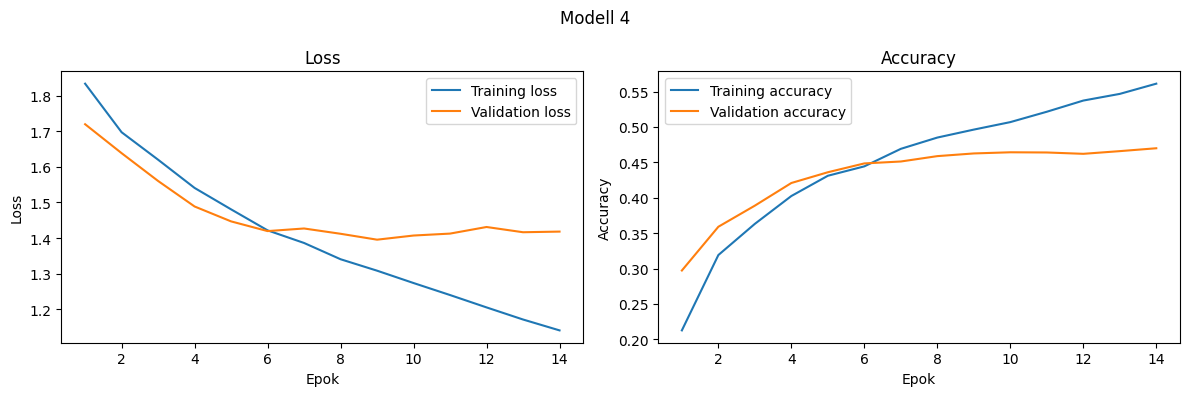

In [63]:
plot_history(history_4_1, title="Modell 4")

#### Modell 4.2, Lägga till BatchNormalization

In [64]:
model_4_2 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [65]:
model_4_2.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [66]:
print("Startar träning av Modell 4.2 (+ BatchNormalization)")
start_time_4_2 = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_4_2 = model_4_2.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    callbacks=[early_stopping]
)

training_time_4_2 = time.time() - start_time_4_2
m42_mins, m42_secs = divmod(training_time_4_2, 60)
print(f"\nTräning avbruten/klar via Early Stopping")
print(f"Total träningstid: {int(m42_mins)}m {int(m42_secs)}s")

Startar träning av Modell 4.2 (+ BatchNormalization)
Epoch 1/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.2400 - loss: 1.8687 - val_accuracy: 0.2622 - val_loss: 1.9677
Epoch 2/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3198 - loss: 1.6831 - val_accuracy: 0.3322 - val_loss: 1.6483
Epoch 3/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3657 - loss: 1.5938 - val_accuracy: 0.3585 - val_loss: 1.5977
Epoch 4/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3896 - loss: 1.5354 - val_accuracy: 0.3951 - val_loss: 1.5417
Epoch 5/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4218 - loss: 1.4678 - val_accuracy: 0.4319 - val_loss: 1.4710
Epoch 6/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4395 - loss: 1.4150 - val_accuracy: 0.4458 - val_loss: 1.4549
Epoch 7/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4643 - loss: 1.3603 - val_accuracy: 0.4322 - val_loss: 1.4546
Epoch 8/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 1

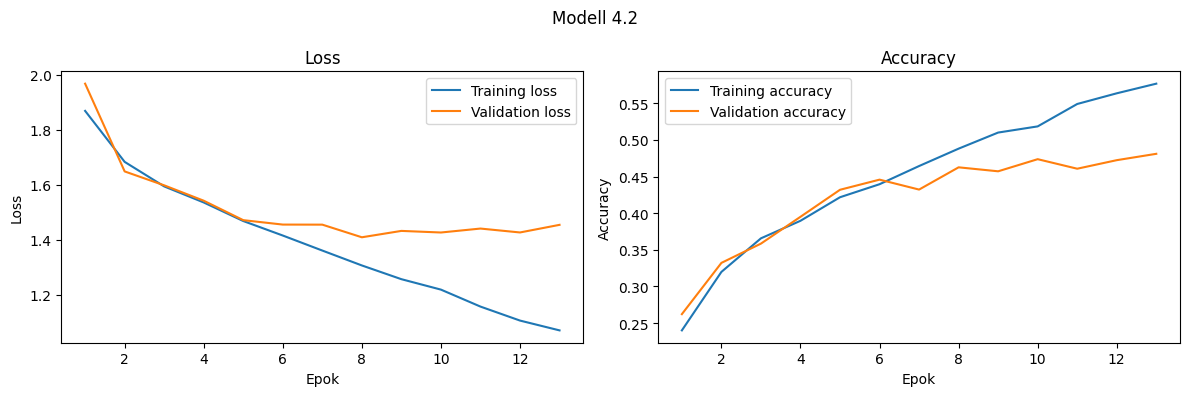

In [67]:
plot_history(history_4_2, title="Modell 4.2")

#### Modell 4.3, ta bort BatchNormalization, men göra nätverket djupare och bredare

In [68]:
model_4_3 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [69]:
model_4_3.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [70]:
print("Startar träning av Modell 4.3 (Djupare & bredare, utan BatchNormalization)")
start_time_4_3 = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_4_3 = model_4_3.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    callbacks=[early_stopping]
)

training_time_4_3 = time.time() - start_time_4_3
m43_mins, m43_secs = divmod(training_time_4_3, 60)
print(f"\nTräning avbruten/klar via Early Stopping")
print(f"Total träningstid: {int(m43_mins)}m {int(m43_secs)}s")

Startar träning av Modell 4.3 (Djupare & bredare, utan BatchNormalization)
Epoch 1/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.1627 - loss: 1.8795 - val_accuracy: 0.1936 - val_loss: 1.8540
Epoch 2/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.2187 - loss: 1.8273 - val_accuracy: 0.2817 - val_loss: 1.7339
Epoch 3/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.2946 - loss: 1.7122 - val_accuracy: 0.3270 - val_loss: 1.6511
Epoch 4/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3561 - loss: 1.6081 - val_accuracy: 0.4132 - val_loss: 1.5324
Epoch 5/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4228 - loss: 1.4766 - val_accuracy: 0.4393 - val_loss: 1.4551
Epoch 6/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4574 - loss: 1.3761 - val_accuracy: 0.4688 - val_loss: 1.3992
Epoch 7/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.5013 - loss: 1.2862 - val_accuracy: 0.4740 - val_loss: 1.3734
Epoch 8/45
461/

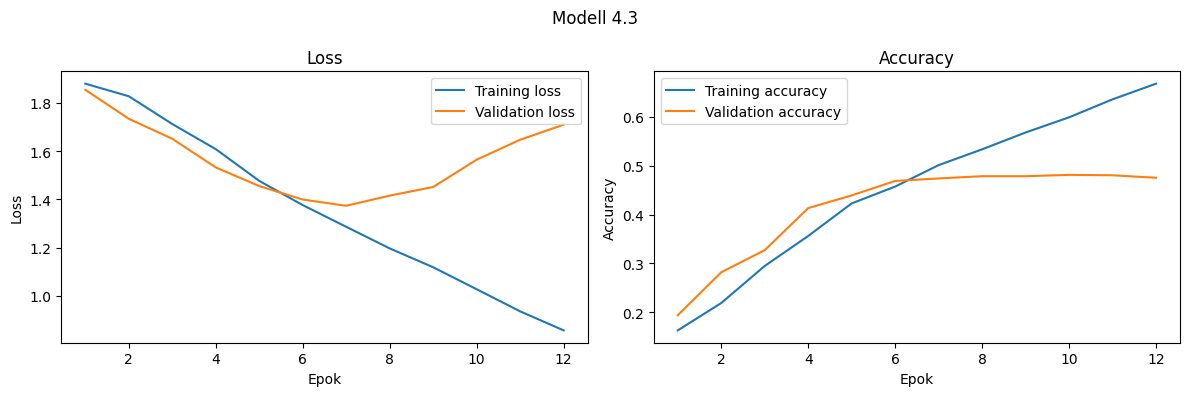

In [71]:
plot_history(history_4_3, title="Modell 4.3")

#### Modell 4.4, byta Flatten() mot GlobalAveragePooling2D()

In [73]:
model_4_4 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

In [74]:
model_4_4.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [75]:
print("Startar träning av Modell 4.4 (+ GlobalAveragePooling2D istället för Flatten)")
start_time_4_4 = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_4_4 = model_4_4.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    callbacks=[early_stopping]
)

training_time_4_4 = time.time() - start_time_4_4
m44_mins, m44_secs = divmod(training_time_4_4, 60)
print(f"\nTräning avbruten/klar via Early Stopping")
print(f"Total träningstid: {int(m44_mins)}m {int(m44_secs)}s")

Startar träning av Modell 4.4 (+ GlobalAveragePooling2D istället för Flatten)
Epoch 1/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.1833 - loss: 1.8646 - val_accuracy: 0.2218 - val_loss: 1.8352
Epoch 2/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.2207 - loss: 1.8224 - val_accuracy: 0.2728 - val_loss: 1.7553
Epoch 3/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.2809 - loss: 1.7182 - val_accuracy: 0.3324 - val_loss: 1.6356
Epoch 4/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.3554 - loss: 1.6118 - val_accuracy: 0.3723 - val_loss: 1.5594
Epoch 5/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4197 - loss: 1.4952 - val_accuracy: 0.4292 - val_loss: 1.4538
Epoch 6/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4601 - loss: 1.3935 - val_accuracy: 0.4544 - val_loss: 1.3947
Epoch 7/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.4995 - loss: 1.3001 - val_accuracy: 0.4816 - val_loss: 1.3661
Epoch 8/45
4

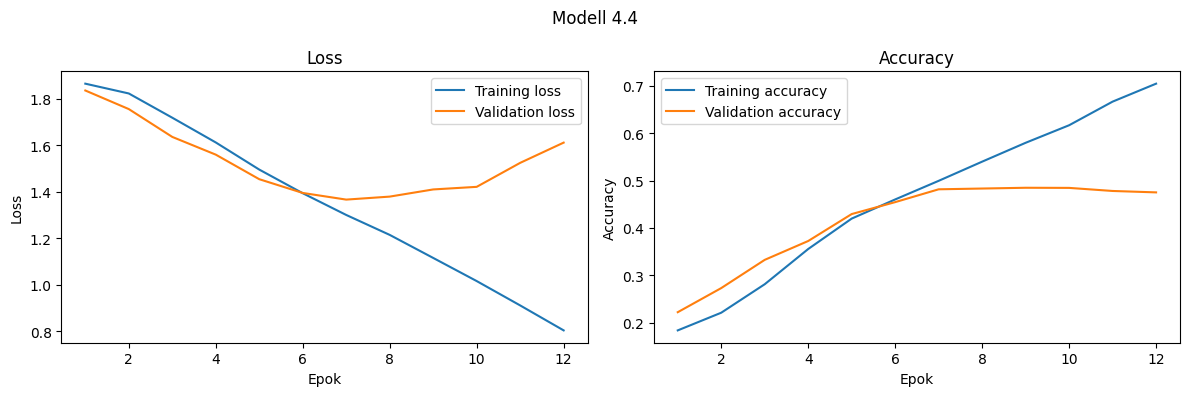

In [76]:
plot_history(history_4_4, title="Modell 4.4")

In [ ]:
# Hämtar gissningarna
y_val_pred_probs = model_4_4.predict(X_val_m2_scaled)
model_4_4_val_pred = np.argmax(y_val_pred_probs, axis=1)

class_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

per_class_data = []

# Loopa igenom varje klass och räkna
for i, class_name in enumerate(class_labels):
    actual_mask = (y_val_m2 == i)
    correct_mask = (y_val_m2 == i) & (model_4_4_val_pred == i)
    
    support = np.sum(actual_mask)   
    correct = np.sum(correct_mask)  
    accuracy = correct / support if support > 0 else 0
    
    per_class_data.append({
        "Känsla": class_name,
        "Antal bilder (Support)": support,
        "Rätt gissade": correct,
        "Accuracy": accuracy
    })

# Skapa dataramen och sortera efter lägst accuracy
per_class_df = pd.DataFrame(per_class_data)
per_class_df = per_class_df.sort_values(by="Accuracy", ascending=True).reset_index(drop=True)

# Visa
per_class_df.style.format({
    "Accuracy": "{:.2%}"
})

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


,Känsla,Antal bilder (Support),Rätt gissade,Accuracy
0,Disgust,88,0,0.00%
1,Fear,600,108,18.00%
2,Angry,600,260,43.33%
3,Sad,600,266,44.33%
4,Surprise,600,279,46.50%
5,Happy,600,382,63.67%
6,Neutral,600,481,80.17%


### 3.5 Modell 5 - keep it balanced

In [89]:
# Beräknar balanserade klassvikter automatiskt
# Detta ger ett straffvärde (vikt) som är omvänt proportionellt mot klassfrekvensen
raw_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_m2),
    y=y_train_m2
)

# Keras vill ha vikterna som en dictionary: {klass_index: vikt}
class_weights_dict = dict(zip(np.unique(y_train_m2), raw_weights))

print("Beräknade klassvikter")
class_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
for i, label in enumerate(class_labels):
    print(f"{label}: {class_weights_dict[i]:.4f}")


# Klona arkitekturen från Modell 4.4
# Detta skapar ett helt tomt och rent "skal" med slumpmässiga startvikter
model_5 = keras.models.clone_model(model_4_4)


# Kompilera
model_5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_m5 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

Beräknade klassvikter
Angry: 0.8779
Disgust: 6.0542
Fear: 0.8779
Happy: 0.8779
Sad: 0.8779
Surprise: 0.8779
Neutral: 0.8779


In [90]:
print("Startar träning av Modell 5 (Modell 4.4 men med class_weights = balanced)")
start_time_5 = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_5 = model_5.fit(
    X_train_m2_scaled, 
    y_train_m2,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_m5]
)

training_time_5 = time.time() - start_time_5
m5_mins, m5_secs = divmod(training_time_5, 60)
print(f"\nTräning avbruten/klar via Early Stopping")
print(f"Total träningstid: {int(m5_mins)}m {int(m5_secs)}s")

Startar träning av Modell 5 (Modell 4.4 men med class_weights = balanced)
Epoch 1/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.1518 - loss: 1.9453 - val_accuracy: 0.1738 - val_loss: 1.9401
Epoch 2/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.1687 - loss: 1.9372 - val_accuracy: 0.2427 - val_loss: 1.9001
Epoch 3/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.2229 - loss: 1.8877 - val_accuracy: 0.2519 - val_loss: 1.8245
Epoch 4/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.2463 - loss: 1.8067 - val_accuracy: 0.2153 - val_loss: 1.8382
Epoch 5/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.2755 - loss: 1.7374 - val_accuracy: 0.2739 - val_loss: 1.7804
Epoch 6/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3220 - loss: 1.6671 - val_accuracy: 0.3099 - val_loss: 1.7073
Epoch 7/45
461/461 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.3571 - loss: 1.5827 - val_accuracy: 0.3476 - val_loss: 1.6306
Epoch 8/45
461/4

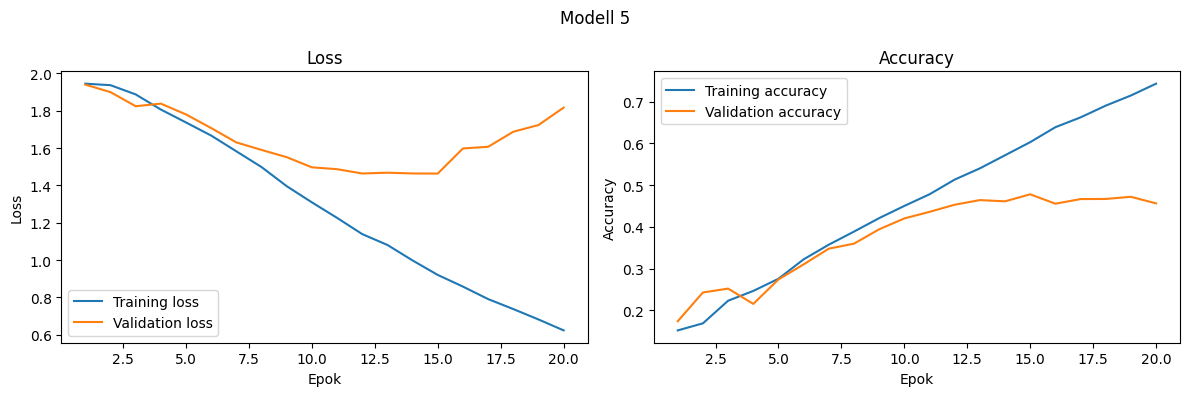

In [91]:
plot_history(history_5, title="Modell 5")

In [ ]:
# Hämtar gissningarna
y_val_pred_probs = model_5.predict(X_val_m2_scaled)
model_5_val_pred = np.argmax(y_val_pred_probs, axis=1)

class_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

per_class_data = []

# Loopa igenom varje klass och räkna
for i, class_name in enumerate(class_labels):
    actual_mask = (y_val_m2 == i)
    correct_mask = (y_val_m2 == i) & (model_5_val_pred == i)
    
    support = np.sum(actual_mask)   
    correct = np.sum(correct_mask)  
    accuracy = correct / support if support > 0 else 0
    
    per_class_data.append({
        "Känsla": class_name,
        "Antal bilder (Support)": support,
        "Rätt gissade": correct,
        "Accuracy": accuracy
    })

# Skapa dataramen och sortera efter lägst accuracy
per_class_df = pd.DataFrame(per_class_data)
per_class_df = per_class_df.sort_values(by="Accuracy", ascending=True).reset_index(drop=True)

# Visa
per_class_df.style.format({
    "Accuracy": "{:.2%}"
})

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


,Känsla,Antal bilder (Support),Rätt gissade,Accuracy
0,Fear,600,98,16.33%
1,Sad,600,246,41.00%
2,Disgust,88,42,47.73%
3,Angry,600,299,49.83%
4,Surprise,600,305,50.83%
5,Happy,600,365,60.83%
6,Neutral,600,407,67.83%


### 3.6 Modell 6 - new data who dis

In [ ]:
# Isolerar alla existerande Disgust-bilder (Klass 1) från träningsdatan
disgust_indices = np.where(y_train_m2 == 1)[0]
X_disgust = X_train_m2_scaled[disgust_indices]
y_disgust = y_train_m2[disgust_indices]

# Räknar ut exakt hur många extra bilder som behöver skapas
target_count = 2400
current_count = len(disgust_indices)
needed_count = target_count - current_count

print(f"Hittade {current_count} originalbilder av Disgust.")
print(f"Genererar {needed_count} nya bilder för att nå {target_count}...")

# Definierar en "augmenterings-pipeline" (Anpassad för ansikten)
data_augmentation_seq = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),       # Speglar ansiktet horisontellt
    layers.RandomRotation(0.1, fill_mode="nearest")  # Roterar lite (max ~36 grader)
])

augmented_images = []
augmented_labels = []

# Genererar bilderna genom att loopa över originalbilderna
for i in range(needed_count):
    # Väljer en slumpmässig Disgust-bild
    base_img = X_disgust[i % current_count]
    
    # Kör augmenteringen
    aug_img = data_augmentation_seq(np.expand_dims(base_img, axis=0), training=True)
    
    augmented_images.append(np.squeeze(aug_img, axis=0))
    augmented_labels.append(1) 

# Omvandlar de nya bilderna till numpy-arrayer
X_disgust_aug = np.array(augmented_images)
y_disgust_aug = np.array(augmented_labels)

# 5. Slår ihop originaldatan med den helt nya augmenterade datan
X_train_augmented = np.concatenate([X_train_m2_scaled, X_disgust_aug], axis=0)
y_train_augmented = np.concatenate([y_train_m2, y_disgust_aug], axis=0)

# Verifiera att det blev rätt
print("\nNy klassfördelning i X_train_augmented")
for idx, label in enumerate(["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]):
    print(f"Klass {idx} ({label}): {np.bincount(y_train_augmented)[idx]} bilder")

Hittade 348 originalbilder av Disgust.
Genererar 2052 nya bilder för att nå 2400...

=== Ny klassfördelning i X_train_augmented ===
Klass 0 (angry): 2400 bilder
Klass 1 (disgust): 2400 bilder
Klass 2 (fear): 2400 bilder
Klass 3 (happy): 2400 bilder
Klass 4 (neutral): 2400 bilder
Klass 5 (sad): 2400 bilder
Klass 6 (surprise): 2400 bilder


In [94]:
# Klona arkitekturen från Modell 4.4
# Detta skapar ett helt tomt och rent "skal" med slumpmässiga startvikter
model_6 = keras.models.clone_model(model_4_4)


# Kompilera
model_6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_m6 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [95]:
print("Startar träning av Modell 5 (Modell 4.4 men med fler disgust-bilder)")
start_time_6 = time.time()

# Tränar modellen och sparar träningsresultatet i en history-variabel
history_6 = model_6.fit(
    X_train_augmented, 
    y_train_augmented,
    validation_data=(X_val_m2_scaled, y_val_m2),
    epochs=45,
    batch_size=32,
    callbacks=[early_stopping_m6]
)

training_time_6 = time.time() - start_time_6
m6_mins, m6_secs = divmod(training_time_6, 60)
print(f"\nTräning avbruten/klar via Early Stopping")
print(f"Total träningstid: {int(m6_mins)}m {int(m6_secs)}s")

Startar träning av Modell 5 (Modell 4.4 men med fler disgust-bilder)
Epoch 1/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.1429 - loss: 1.9461 - val_accuracy: 0.1714 - val_loss: 1.9459
Epoch 2/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.1434 - loss: 1.9461 - val_accuracy: 0.1990 - val_loss: 1.9364
Epoch 3/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.1724 - loss: 1.9352 - val_accuracy: 0.0887 - val_loss: 1.9732
Epoch 4/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.2348 - loss: 1.8645 - val_accuracy: 0.2172 - val_loss: 1.8334
Epoch 5/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.3063 - loss: 1.7312 - val_accuracy: 0.2985 - val_loss: 1.6874
Epoch 6/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.3527 - loss: 1.6319 - val_accuracy: 0.3297 - val_loss: 1.6538
Epoch 7/45
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.3869 - loss: 1.5655 - val_accuracy: 0.3644 - val_loss: 1.6131
Epoch 8/45
525/525 ━━

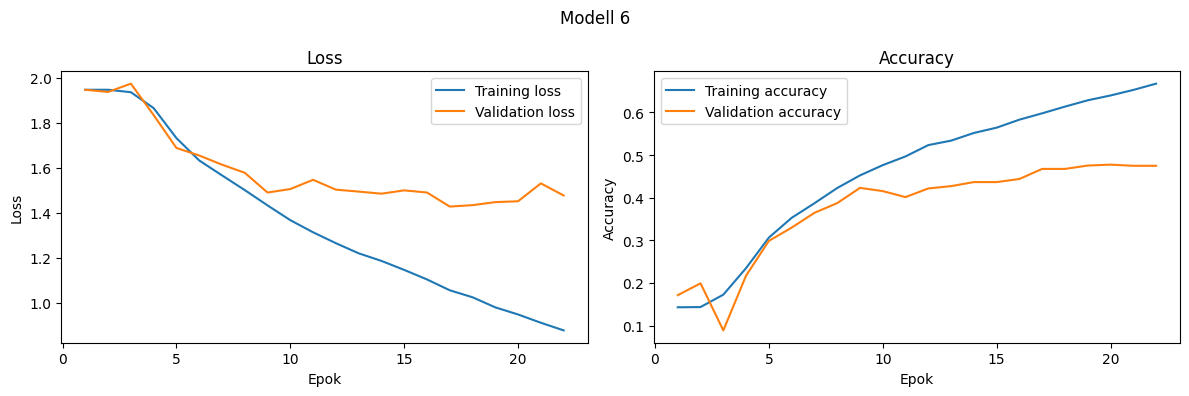

In [96]:
plot_history(history_6, title="Modell 6")

In [97]:
# Hämtar gissningarna
y_val_pred_probs = model_6.predict(X_val_m2_scaled)
model_6_val_pred = np.argmax(y_val_pred_probs, axis=1)

class_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

per_class_data = []

# Loopa igenom varje klass och räkna
for i, class_name in enumerate(class_labels):
    actual_mask = (y_val_m2 == i)
    correct_mask = (y_val_m2 == i) & (model_6_val_pred == i)
    
    support = np.sum(actual_mask)   
    correct = np.sum(correct_mask)  
    accuracy = correct / support if support > 0 else 0
    
    per_class_data.append({
        "Känsla": class_name,
        "Antal bilder (Support)": support,
        "Rätt gissade": correct,
        "Accuracy": accuracy
    })

# Skapa dataramen och sortera efter lägst accuracy
per_class_df = pd.DataFrame(per_class_data)
per_class_df = per_class_df.sort_values(by="Accuracy", ascending=True).reset_index(drop=True)

# Visa
per_class_df.style.format({
    "Accuracy": "{:.2%}"
})

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


,Känsla,Antal bilder (Support),Rätt gissade,Accuracy
0,Fear,600,85,14.17%
1,Angry,600,155,25.83%
2,Disgust,88,31,35.23%
3,Surprise,600,233,38.83%
4,Sad,600,341,56.83%
5,Happy,600,418,69.67%
6,Neutral,600,461,76.83%


## 4. Utvärdering

## 5. Prediktioner på ny data

## 6. Analys av resultatet

## 7. Reflektion